### THIS CODE DESPERATELY NEEDS CLEANING UP THIS IS ABYSMAL HAHAHAHAHAHAHAHAHAHAHAHAH

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy import optimize
from astropy import units as u
from IPython.display import HTML

In [2]:
# define M (mean anomaly) (for earth, change r for other planets)
def M_anomaly(t, T, r = 1):
    P = 31558150
    M = (2 * np.pi * (t - T)) / P
    return M

# calculate e (eccentricity). But r_a and r_p must change over time so eventually those should also become functions?
eccentricity = (152098000000 - 147098000000) / (152098000000 + 147098000000)

In [3]:
# solve kepler's equation for E (eccentric anomaly): E must be iteratively determined

# define equation for M = E - esin(E)
def E_anomaly(E, M, e = eccentricity):
    return E - e * np.sin(E) - M

# define derivative of kepler's equation
def derive_E(E, M, e = eccentricity):
    return 1 - e * np.cos(E)

In [4]:
# creating an empty array for x and y coordinates for the orbit
x_coords = []
y_coords = []

# determine roots https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html
period = 31558150
a = (1 * u.au).to(u.m).value

time_array = np.linspace(0, period, 100)

# create the orbit for time t
for t in time_array:
    M = M_anomaly(t, period)
    E = optimize.newton(E_anomaly, M, derive_E, args = (M, eccentricity), maxiter = 50)
    x = a * np.cos(E) - eccentricity
    y = a * np.sqrt(1 - eccentricity ** 2) * np.sin(E)

    x_coords.append(x)
    y_coords.append(y)

x_array = np.array(x_coords)
y_array = np.array(y_coords)

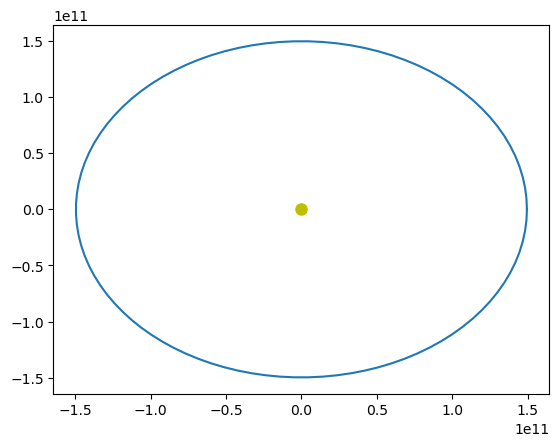

In [5]:
plt.plot(x_array, y_array)
plt.plot(0, 0, 'yo', markersize = 8)
plt.show()

In [7]:
# animate the orbit yay https://matplotlib.org/stable/api/animation_api.html

fig, ax = plt.subplots()
ax.set_xlim(-1.2 * a, 1.2 * a)
ax.set_ylim(-1.2 * a, 1.2 * a)

ax.plot(0, 0, 'yo', markersize = 8)

planet, = ax.plot([], [], 'bo', markersize = 6)
orbit_trail, = ax.plot([], [], 'b-')

def animate(frame):
    planet.set_data([x_array[frame]], [y_array[frame]])
    orbit_trail.set_data([x_array[:frame + 1]], [y_array[:frame + 1]])
    return planet, orbit_trail

ani = animation.FuncAnimation(
    fig, animate, frames = len(time_array), interval = 50, blit = True
)

plt.close()

HTML(ani.to_jshtml())